# Cliff-Lorimer quantification on denormalized EDX volumes

Loads reconstructed elemental intensity maps (TIFF, one per element), runs
Cliff-Lorimer and saves atomic-percent maps.

**Input**: denormalized volumes in physical intensity units (counts, a.u.).  
DIPm/DIPs outputs must be denormalized **before** quantification — set
`DENORM = True` and provide `VMAX_LIST` if loading normalized TIFFs.

---
## Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tifffile

from dl_etomo.quantification import quantify_cl_vol

---
## ▶ Configuration — edit this cell

In [2]:
# ---------------------------------------------------------------------------
# Elements and X-ray lines  (must be in the SAME ORDER as the TIFF files)
# ---------------------------------------------------------------------------
ELEMENTS   = ['Ge', 'Sb', 'Te']
XRAY_LINES = ['Ge_Ka', 'Sb_La', 'Te_La']

# ---------------------------------------------------------------------------
# Input: one TIFF file per element (volume or 2-D map)
#   • If already denormalized  → DENORM = False
#   • If DIPm/DIPs output (normalized [0,1]) → DENORM = True and set VMAX_LIST
# ---------------------------------------------------------------------------
INPUT_DIR  = Path('../../Data/EDX_results/SET')

# One file per element, in the same order as ELEMENTS
INPUT_FILES = [INPUT_DIR / f'DIP_recon_SET_{el}_it1499_tv1e-11_lr0.0005_nr0.05_L2.tif'
               for el in ELEMENTS]

# Denormalization
DENORM    = False                  # True if files are normalized [0,1]
VMAX_LIST = [2.93, 1.80, 2.16]    # vmax per element (only used if DENORM=True)

# ---------------------------------------------------------------------------
# Masking (removes background before CL quantification)
#   AUTO_MASK = True  → Otsu threshold on the sum of all channels (recommended)
#   MASK_FILE = path  → load a pre-computed binary mask TIFF (overrides AUTO_MASK)
#   Set both to None/False to skip masking.
# ---------------------------------------------------------------------------
AUTO_MASK = True         # recommended: Otsu mask from sum of channels
MASK_FILE = None         # or Path('...') to a pre-saved binary mask TIFF

# Output directory for atomic-percent TIFF maps
OUT_DIR    = INPUT_DIR / 'quantification'

# ---------------------------------------------------------------------------
# Visualization (only relevant for 3-D volumes)
#   SHOW_AXIS  : 0 = Z/depth, 1 = Y, 2 = X
#   SHOW_SLICE : index along that axis
# ---------------------------------------------------------------------------
SHOW_AXIS  = 1
SHOW_SLICE = 49

---
## Load intensity maps

In [3]:
intensity_maps = []
for el, fp in zip(ELEMENTS, INPUT_FILES):
    vol = tifffile.imread(str(fp)).astype(np.float32)
    vol[vol < 0] = 0.0
    print(f'  {el:4s}  {str(fp.name):<60s}  shape={vol.shape}  '
          f'min={vol.min():.4g}  max={vol.max():.4g}')
    intensity_maps.append(vol)

if DENORM:
    print('\nDenormalizing...')
    for i, vmax in enumerate(VMAX_LIST):
        intensity_maps[i] = intensity_maps[i] * vmax
        print(f'  {ELEMENTS[i]:4s}  x vmax={vmax:.4g}  '
              f'-> max={intensity_maps[i].max():.4g}')
else:
    print('\nFiles assumed already denormalized — skipping.')

  Ge    DIP_recon_SET_Ge_it1499_tv1e-11_lr0.0005_nr0.05_L2.tif        shape=(176, 112, 112)  min=8.791e-17  max=7.427
  Sb    DIP_recon_SET_Sb_it1499_tv1e-11_lr0.0005_nr0.05_L2.tif        shape=(176, 112, 112)  min=5.959e-16  max=5.202
  Te    DIP_recon_SET_Te_it1499_tv1e-11_lr0.0005_nr0.05_L2.tif        shape=(176, 112, 112)  min=1.284e-16  max=5.299

Files assumed already denormalized — skipping.


---
## Run Cliff-Lorimer quantification

In [4]:
# Resolve mask
user_mask = None
if MASK_FILE is not None:
    user_mask = tifffile.imread(str(MASK_FILE)).astype(float)
    print(f'Loaded mask from {MASK_FILE}  shape={user_mask.shape}')

print('Running Cliff-Lorimer quantification...')
atomic_percent = quantify_cl_vol(
    intensity_maps,
    XRAY_LINES,
    absorption=None,
    mask=user_mask,
    auto_mask=(AUTO_MASK and user_mask is None),
)

for el, ap in zip(ELEMENTS, atomic_percent):
    print(f'  {el:4s}  mean={np.nanmean(ap):.2f}%  '
          f'min={np.nanmin(ap):.2f}%  max={np.nanmax(ap):.2f}%')

Running Cliff-Lorimer quantification...
[auto_mask] Otsu threshold=3.337  foreground voxels=95129 / 2207744
  Ge    mean=2.48%  min=0.00%  max=100.00%
  Sb    mean=0.64%  min=0.00%  max=61.37%
  Te    mean=1.19%  min=0.00%  max=68.43%


---
## Visualize

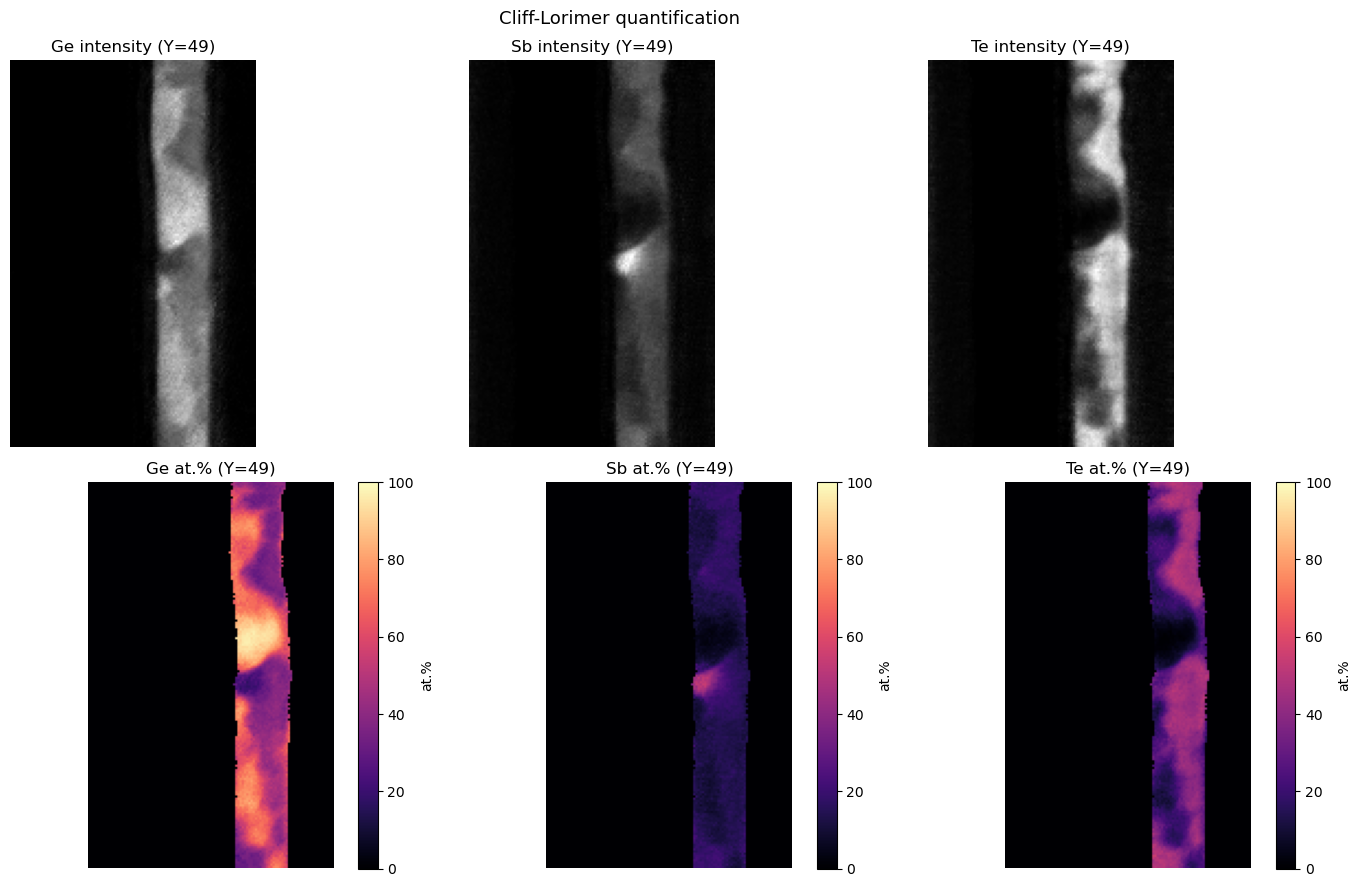

In [5]:
ndim = np.array(atomic_percent[0]).ndim
E    = len(ELEMENTS)

AXIS_LABEL = {0: 'Z/depth', 1: 'Y', 2: 'X'}

fig, axes = plt.subplots(2, E, figsize=(5 * E, 9))

for i, (el, ap) in enumerate(zip(ELEMENTS, atomic_percent)):
    ap = np.array(ap)
    if ndim == 3:
        sl_i = np.take(intensity_maps[i], SHOW_SLICE, axis=SHOW_AXIS)
        sl_q = np.take(ap,                SHOW_SLICE, axis=SHOW_AXIS)
        slice_label = f'{AXIS_LABEL[SHOW_AXIS]}={SHOW_SLICE}'
    else:
        sl_i = intensity_maps[i]
        sl_q = ap
        slice_label = '2D'

    axes[0, i].imshow(sl_i, cmap='gray')
    axes[0, i].set_title(f'{el} intensity ({slice_label})')
    axes[0, i].axis('off')

    im = axes[1, i].imshow(sl_q, cmap='magma', vmin=0, vmax=100)
    axes[1, i].set_title(f'{el} at.% ({slice_label})')
    axes[1, i].axis('off')
    plt.colorbar(im, ax=axes[1, i], fraction=0.046, label='at.%')

plt.suptitle('Cliff-Lorimer quantification', fontsize=13)
plt.tight_layout()
plt.show()

---
## Save atomic-percent TIFF maps

In [6]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

for el, ap in zip(ELEMENTS, atomic_percent):
    out_path = OUT_DIR / f'quant_CL_{el}_atpct.tif'
    tifffile.imwrite(
        str(out_path),
        np.array(ap).astype(np.float32),
        imagej=True,
        metadata={'axes': 'ZYX' if ndim == 3 else 'YX'},
    )
    print(f'Saved: {out_path}')

Saved: ..\..\Data\EDX_results\SET\quantification\quant_CL_Ge_atpct.tif
Saved: ..\..\Data\EDX_results\SET\quantification\quant_CL_Sb_atpct.tif
Saved: ..\..\Data\EDX_results\SET\quantification\quant_CL_Te_atpct.tif
